In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error

import joblib

In [3]:
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


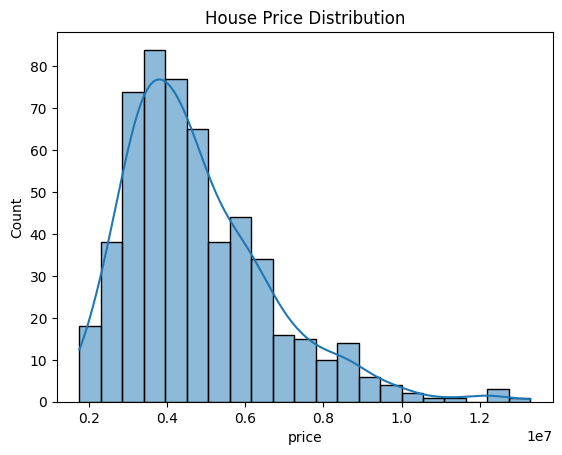

In [7]:
sns.histplot(df['price'], kde=True)
plt.title("House Price Distribution")
plt.show()

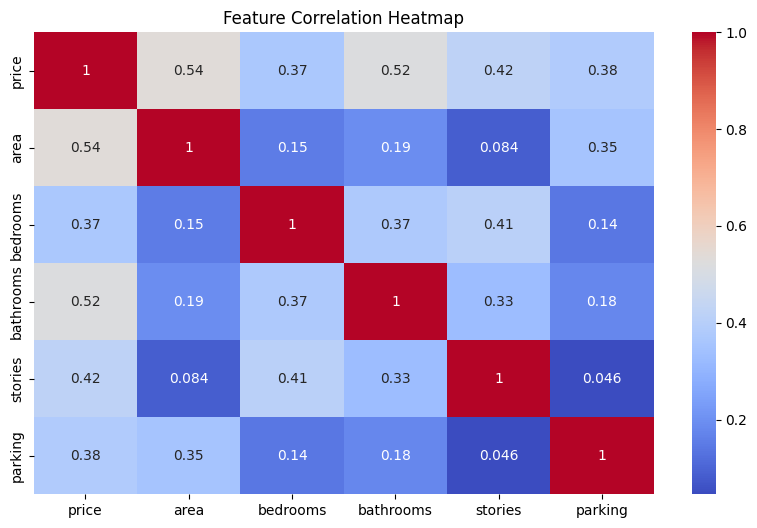

In [9]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

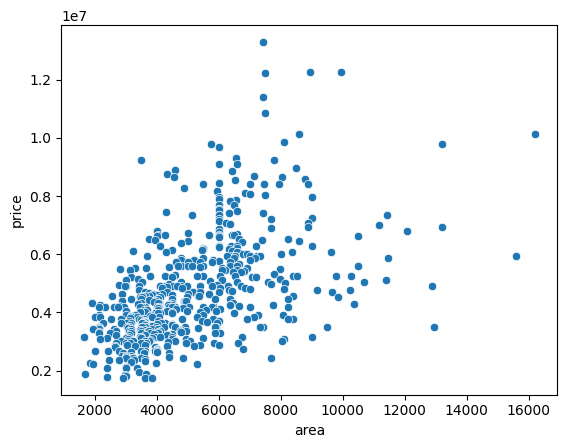

In [10]:
sns.scatterplot(x="area", y="price", data=df)
plt.show()

In [11]:
df['price_log'] = np.log(df['price'])

In [12]:
df = pd.get_dummies(df, drop_first=True)

In [13]:
X = df.drop(['price','price_log'], axis=1)
y = df['price_log']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [17]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [18]:
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

In [19]:
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

print("Linear Regression:", evaluate(y_test, lr_pred))
print("Random Forest:", evaluate(y_test, rf_pred))
print("Gradient Boosting:", evaluate(y_test, gb_pred))

Linear Regression: (np.float64(0.2515821402917184), 0.19990272792834868)
Random Forest: (np.float64(0.26485571434274463), 0.20735010417909358)
Gradient Boosting: (np.float64(0.25231767889012097), 0.19773491452437295)


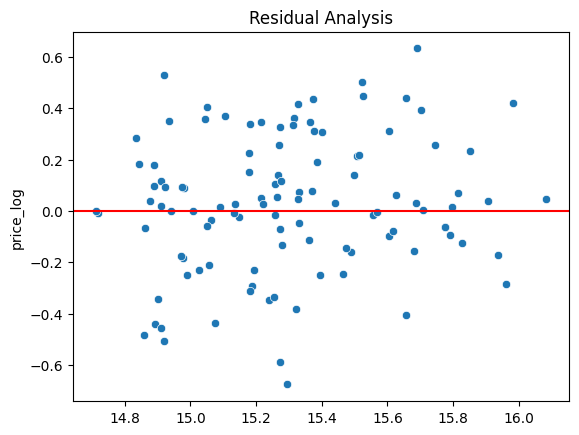

In [20]:
residuals = y_test - rf_pred

sns.scatterplot(x=rf_pred, y=residuals)
plt.axhline(0, color='red')
plt.title("Residual Analysis")
plt.show()

In [21]:
joblib.dump(rf, "house_price_model.pkl")

['house_price_model.pkl']

In [25]:
from google.colab import files
files.download("house_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
import joblib
import numpy as np

# Load trained model
model = joblib.load("house_price_model.pkl")

# Example input with all 13 features (unscaled), in the order the model expects:
# Features (from X dataframe before scaling):
# 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
# 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
# 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished',
# 'furnishingstatus_unfurnished'

# Example house parameters:
# area=3000, bedrooms=3, bathrooms=2, stories=2, parking=1
# mainroad=yes, guestroom=no, basement=no, hotwaterheating=no,
# airconditioning=yes, prefarea=no,
# furnishingstatus=semi-furnished (meaning not furnished, not unfurnished)

sample_house = np.array([[3000, 3, 2, 2, 1, # numerical features
                          1, 0, 0, 0, 1, 0, # binary 'yes' features
                          1, 0]]) # furnishingstatus_semi-furnished=1, furnishingstatus_unfurnished=0

# Predict (model outputs log(price) since it was trained on price_log)
# IMPORTANT: The model was trained on SCALED data. Passing unscaled data here
# will lead to inaccurate predictions. For accurate results, the input data
# should be scaled using the same scaler used during training, or the model
# should be re-trained without scaling.
prediction_log = model.predict(sample_house)

# Convert back to actual price
prediction_price = np.exp(prediction_log)

print("Predicted Price (without scaler, potentially inaccurate):", prediction_price[0])

Predicted Price (without scaler, potentially inaccurate): 7595698.536389269
